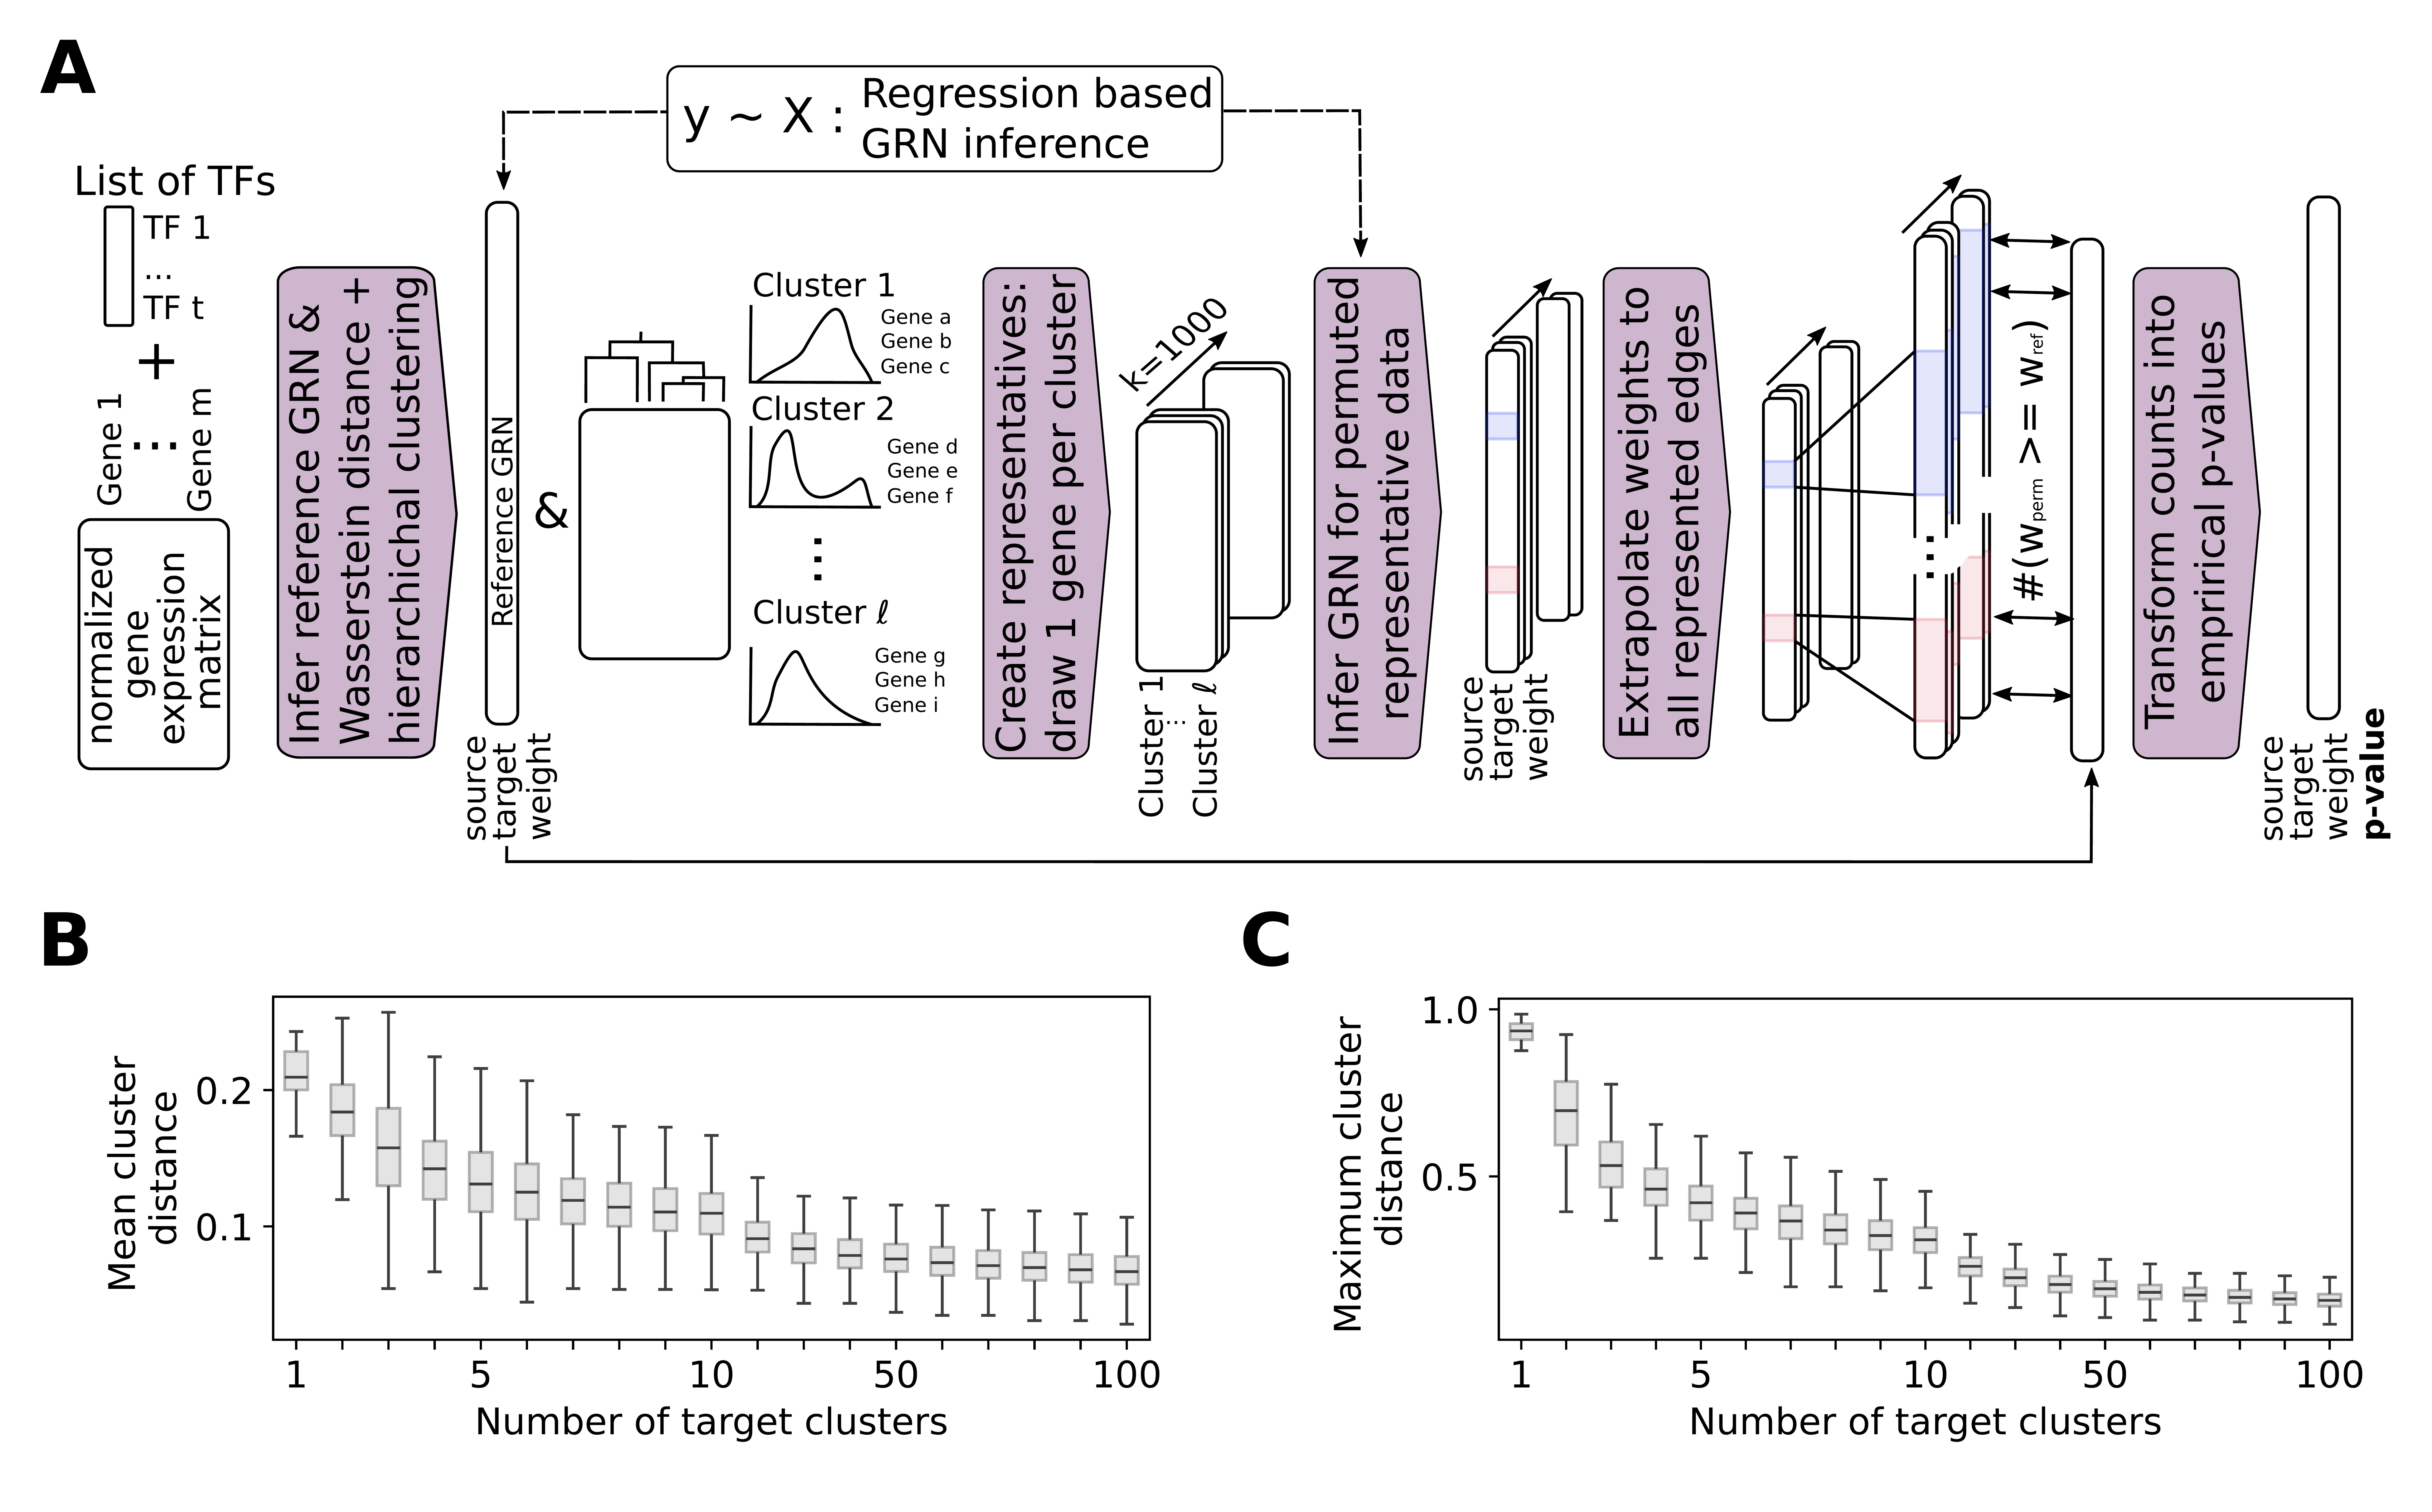

In [1]:

import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from pdf2image import convert_from_path
from matplotlib.gridspec import GridSpec

plt.rcdefaults()

pdf_files = [
    'flowchart.pdf',
    'mean_cluster_distances_smaller.pdf',
    'max_cluster_distances_smaller.pdf',
]

images = [
    convert_from_path(pdf, dpi=1200, first_page=1, last_page=1)[0]
    for pdf in pdf_files
]

fig = plt.figure(figsize=(8, 5), dpi=1200)

gs = GridSpec(
    2, 2,
    figure=fig,
    width_ratios=[1, 1],
    height_ratios=[1.6, 1],
    wspace=0.075,
    hspace=0.1,
)

axA = fig.add_subplot(gs[0, :])
axB = fig.add_subplot(gs[1, 0])
axC = fig.add_subplot(gs[1, 1])

for ax, img in zip([axA, axB, axC], images):
    ax.imshow(img)
    ax.axis('off')

for label, ax in zip(list('ABC'), [axA, axB, axC]):
    if label == 'A':
        x_pos, y_pos = 0.03, 0.90
    else:
        x_pos, y_pos = 0.06, 0.90

    trans = mtransforms.ScaledTranslation(-20 / 72, 7 / 72, fig.dpi_scale_trans)
    ax.text(
        x_pos,
        y_pos,
        label,
        transform=ax.transAxes + trans,
        fontsize=14,
        va='bottom',
        fontfamily='sans-serif',
        fontweight='bold'
    )

fig.savefig('overview.pdf', bbox_inches='tight')
